# FT5010 Final-Term Project — Forex Momentum Strategy Backtester

## Strategy: Dual Moving Average Crossover with RSI Filter

**Strategy Description:**
This strategy trades a universe of USD major forex pairs using a trend-following approach:
- **Signal:** A fast moving average (e.g. 20-period EMA) crossing above/below a slow moving average (e.g. 50-period EMA) generates buy/sell signals.
- **RSI Filter:** Trades are only taken when the RSI confirms momentum — long signals require RSI > 50, short signals require RSI < 50. This reduces false signals in ranging markets.
- **Universe:** USD major pairs — EUR/USD, GBP/USD, USD/JPY, USD/CHF, AUD/USD, USD/CAD, NZD/USD
- **Frequency:** 1-hour bars
- **Backtester:** Event-based (simulates realistic order-by-order execution)

**Backtesting Design:**
- Out-of-sample testing: 70% train / 30% test split
- Parameters optimised on train set, evaluated on test set
- Performance reported for both train and test sets

---

## 0. Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install yfinance pandas numpy matplotlib seaborn scipy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from copy import deepcopy
import itertools

try:
    import yfinance as yf
    print("yfinance loaded successfully.")
except ImportError:
    print("Please run: pip install yfinance")

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("All imports successful.")

yfinance loaded successfully.
All imports successful.


## 1. Configuration

In [2]:
# ─────────────────────────────────────────────
#  GLOBAL CONFIG  — edit these as needed
# ─────────────────────────────────────────────

# USD Major pairs (Yahoo Finance ticker format)
PAIRS = [
    'EURUSD=X',   # EUR/USD
    'GBPUSD=X',   # GBP/USD
    'JPY=X',      # USD/JPY
    'CHF=X',      # USD/CHF
    'AUDUSD=X',   # AUD/USD
    'CAD=X',      # USD/CAD
    'NZDUSD=X',   # NZD/USD
]

PAIR_NAMES = {
    'EURUSD=X': 'EUR/USD',  'GBPUSD=X': 'GBP/USD',
    'JPY=X':    'USD/JPY',  'CHF=X':    'USD/CHF',
    'AUDUSD=X': 'AUD/USD',  'CAD=X':    'USD/CAD',
    'NZDUSD=X': 'NZD/USD',
}
USD_BASE_PAIRS = {'JPY=X', 'CHF=X', 'CAD=X'}

# ── Data period ───────────────────────────────────────────────
from datetime import datetime, timedelta as _td
_today     = datetime.today()
START_DATE = (_today - _td(days=700)).strftime('%Y-%m-%d')
END_DATE   = _today.strftime('%Y-%m-%d')
INTERVAL   = '1h'
TRAIN_RATIO = 0.70

# ── EMA + Signal parameters ──────────────────────────────────
FAST_WINDOW  = 20     # Fast EMA period
SLOW_WINDOW  = 50     # Slow EMA period
TREND_WINDOW = 200    # Long-term trend filter EMA
RSI_WINDOW   = 14     # RSI lookback

# ── Filter thresholds ────────────────────────────────────────
RSI_LONG_THRESH   = 55   # Min RSI for long entry
RSI_SHORT_THRESH  = 45   # Max RSI for short entry
RSI_EXIT_LONG     = 75   # Take-profit: exit long when RSI reaches this
RSI_EXIT_SHORT    = 25   # Take-profit: exit short when RSI reaches this
ADX_WINDOW        = 14   # ADX lookback period
ADX_THRESHOLD     = 25   # Only trade when ADX > this (strong trend)

# ── Session filter (UTC hours) ───────────────────────────────
SESSION_START_UTC = 7    # London open
SESSION_END_UTC   = 17   # New York close

# ── Risk / execution parameters ──────────────────────────────
INITIAL_CAPITAL = 10_000
RISK_PER_TRADE  = 0.01     # 1% equity per trade
RISK_FREE_RATE  = 0.04     # For Sharpe calculation
SPREAD_PIPS     = 2        # Simulated spread in pips
ATR_STOP_MULT   = 2.5      # Initial stop = ATR × this
TRAIL_ATR_MULT  = 2.0      # Trailing stop = ATR × this (tighter than initial)
LEVERAGE        = 50       # Max leverage cap

print('Configuration loaded.')
print(f'Data     : {START_DATE} → {END_DATE} | {INTERVAL}')
print(f'Strategy : EMA({FAST_WINDOW}/{SLOW_WINDOW}) + Trend({TREND_WINDOW}) + RSI({RSI_WINDOW})')
print(f'Filters  : ADX > {ADX_THRESHOLD} | RSI entry {RSI_SHORT_THRESH}-{RSI_LONG_THRESH}')
print(f'           RSI exit: Long@{RSI_EXIT_LONG} Short@{RSI_EXIT_SHORT}')
print(f'Session  : {SESSION_START_UTC}:00–{SESSION_END_UTC}:00 UTC')
print(f'Stops    : Initial {ATR_STOP_MULT}×ATR, Trail {TRAIL_ATR_MULT}×ATR')


Configuration loaded.
Data     : 2024-05-08 → 2026-04-08 | 1h
Strategy : EMA(20/50) + Trend(200) + RSI(14)
Filters  : ADX > 25 | RSI entry 45-55
           RSI exit: Long@75 Short@25
Session  : 7:00–17:00 UTC
Stops    : Initial 2.5×ATR, Trail 2.0×ATR


## 2. Data Fetching

In [3]:
def fetch_forex_data(pairs: list, start: str, end: str, interval: str) -> Dict[str, pd.DataFrame]:
    """
    Fetch OHLCV data for a list of forex pairs from Yahoo Finance.
    Returns a dict: {ticker: DataFrame with Open/High/Low/Close/Volume}

    Handles:
    - Multi-level column headers (yfinance >= 0.2.x)
    - Mixed column capitalisation
    - Timezone-aware vs naive DatetimeIndex
    - Missing Volume column (forex has no real volume)
    """
    data = {}
    for pair in pairs:
        name = PAIR_NAMES.get(pair, pair)
        print(f'  Fetching {name}...', end=' ')
        try:
            df = yf.download(pair, start=start, end=end, interval=interval,
                             progress=False, auto_adjust=True)
            if df.empty:
                print('NO DATA — skipping (check date range or ticker)')
                continue

            # Flatten MultiIndex columns (yfinance sometimes returns ('Close','EURUSD=X'))
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # Normalise column names to Title Case
            df.columns = [str(c).strip().title() for c in df.columns]

            # Ensure required columns exist
            for col in ['Open', 'High', 'Low', 'Close']:
                if col not in df.columns:
                    print(f'MISSING {col} — columns found: {list(df.columns)} — skipping')
                    break
            else:
                if 'Volume' not in df.columns:
                    df['Volume'] = 0  # Forex has no exchange volume

                df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
                df.dropna(subset=['Open', 'High', 'Low', 'Close'], inplace=True)

                # Ensure tz-naive index for consistent merging
                df.index = pd.to_datetime(df.index)
                if df.index.tz is not None:
                    df.index = df.index.tz_localize(None)

                data[pair] = df
                print(f'{len(df):,} bars  [{df.index[0].date()} → {df.index[-1].date()}]')
                continue
            # If we broke out of the for loop (missing column), skip this pair
        except Exception as e:
            print(f'ERROR: {e}')

    return data


print('Fetching 1-hour forex data...')
raw_data = fetch_forex_data(PAIRS, START_DATE, END_DATE, INTERVAL)

print(f'\nSuccessfully loaded: {[PAIR_NAMES.get(p,p) for p in raw_data]}')
if not raw_data:
    raise RuntimeError(
        'No data fetched!\n'
        'Possible fixes:\n'
        '  1. pip install --upgrade yfinance\n'
        '  2. Make sure START_DATE is within the last 730 days\n'
        '  3. Check your internet connection'
    )


Fetching 1-hour forex data...
  Fetching EUR/USD... 11,799 bars  [2024-05-07 → 2026-04-07]
  Fetching GBP/USD... 11,801 bars  [2024-05-07 → 2026-04-07]
  Fetching USD/JPY... 11,732 bars  [2024-05-07 → 2026-04-07]
  Fetching USD/CHF... 11,759 bars  [2024-05-07 → 2026-04-07]
  Fetching AUD/USD... 11,864 bars  [2024-05-07 → 2026-04-07]
  Fetching USD/CAD... 11,866 bars  [2024-05-07 → 2026-04-07]
  Fetching NZD/USD... 11,864 bars  [2024-05-07 → 2026-04-07]

Successfully loaded: ['EUR/USD', 'GBP/USD', 'USD/JPY', 'USD/CHF', 'AUD/USD', 'USD/CAD', 'NZD/USD']


In [4]:
# Quick data inspection
for pair, df in raw_data.items():
    print(f"{PAIR_NAMES[pair]:10s}: {df.index[0].date()} → {df.index[-1].date()} | {len(df):,} bars | "
          f"Price range: {df['Close'].min():.5f} – {df['Close'].max():.5f}")

EUR/USD   : 2024-05-07 → 2026-04-07 | 11,799 bars | Price range: 1.01958 – 1.20467
GBP/USD   : 2024-05-07 → 2026-04-07 | 11,801 bars | Price range: 1.21077 – 1.38500
USD/JPY   : 2024-05-07 → 2026-04-07 | 11,732 bars | Price range: 139.85100 – 161.93800
USD/CHF   : 2024-05-07 → 2026-04-07 | 11,759 bars | Price range: 0.76089 – 0.91944
AUD/USD   : 2024-05-07 → 2026-04-07 | 11,864 bars | Price range: 0.59525 – 0.71844
USD/CAD   : 2024-05-07 → 2026-04-07 | 11,866 bars | Price range: 1.34203 – 1.47812
NZD/USD   : 2024-05-07 → 2026-04-07 | 11,864 bars | Price range: 0.55118 – 0.63755


## 3. Feature Engineering — Indicators

In [5]:
def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Compute Relative Strength Index (RSI)."""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_atr(df: pd.DataFrame, window: int = 14) -> pd.Series:
    """Compute Average True Range (ATR)."""
    high, low, close = df['High'], df['Low'], df['Close']
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(span=window, min_periods=window).mean()


def compute_adx(df: pd.DataFrame, window: int = ADX_WINDOW) -> pd.Series:
    """
    Compute Average Directional Index (ADX) — measures trend STRENGTH.
    ADX > 25 → strong trend, ADX < 20 → no trend / ranging.
    This is the single most impactful filter for trend-following strategies.
    """
    high, low, close = df['High'], df['Low'], df['Close']

    # +DM / -DM (directional movement)
    up_move   = high - high.shift(1)
    down_move = low.shift(1) - low
    plus_dm   = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0)

    # True Range
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)

    # Smoothed using Wilder's method (EWM with com=window-1)
    atr_s     = tr.ewm(com=window - 1, min_periods=window).mean()
    # BUG FIX: pd.Series(plus_dm) must preserve the original DatetimeIndex,
    # otherwise division by atr_s (which has DatetimeIndex) produces all NaN.
    plus_di   = 100 * pd.Series(plus_dm, index=df.index).ewm(com=window - 1, min_periods=window).mean()  / atr_s
    minus_di  = 100 * pd.Series(minus_dm, index=df.index).ewm(com=window - 1, min_periods=window).mean() / atr_s

    # DX and ADX
    dx  = (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan) * 100
    adx = dx.ewm(com=window - 1, min_periods=window).mean()
    return adx


def add_indicators(df: pd.DataFrame,
                   fast:       int = FAST_WINDOW,
                   slow:       int = SLOW_WINDOW,
                   trend_win:  int = TREND_WINDOW,
                   rsi_window: int = RSI_WINDOW) -> pd.DataFrame:
    """
    IMPROVED Strategy: EMA Crossover + ADX + RSI + Trend + Session Filter.

    Improvements over baseline:
    1. ADX filter (>25): Only trade when a real trend exists. This alone
       eliminates most whipsaw losses in ranging markets.
    2. Session filter: Only enter during London/NY hours (07–17 UTC)
       when forex has real volume and directional moves.
    3. RSI extreme exit signal: When RSI hits 75+ (long) or 25- (short),
       signal goes flat to take profit before the trend reverses.
    4. Crossover-event only entries (unchanged from previous fix).
    """
    df = df.copy()
    close = df['Close']

    # ── Core indicators ──────────────────────────────────────────
    df['ema_fast']  = close.ewm(span=fast,      min_periods=fast).mean()
    df['ema_slow']  = close.ewm(span=slow,      min_periods=slow).mean()
    df['ema_trend'] = close.ewm(span=trend_win, min_periods=trend_win).mean()
    df['rsi']       = compute_rsi(close, rsi_window)
    df['atr']       = compute_atr(df)
    df['adx']       = compute_adx(df)

    # ── Regime and crossover ─────────────────────────────────────
    df['regime']    = np.where(df['ema_fast'] > df['ema_slow'], 1, -1)
    df['crossover'] = df['regime'].diff().fillna(0).ne(0)

    # ── Session filter: only allow entries during London/NY ──────
    if hasattr(df.index, 'hour'):
        df['in_session'] = (df.index.hour >= SESSION_START_UTC) & (df.index.hour < SESSION_END_UTC)
    else:
        df['in_session'] = True  # fallback if no hour info

    # ── Combined entry filters ───────────────────────────────────
    trend_long  = close > df['ema_trend']
    trend_short = close < df['ema_trend']
    rsi_long    = df['rsi'] >= RSI_LONG_THRESH
    rsi_short   = df['rsi'] <= RSI_SHORT_THRESH
    adx_ok      = df['adx'] >= ADX_THRESHOLD      # NEW: trend strength filter
    session_ok  = df['in_session']                 # NEW: session filter

    long_ok  = trend_long  & rsi_long  & adx_ok & session_ok
    short_ok = trend_short & rsi_short & adx_ok & session_ok

    # ── Signal: entry on crossover events ────────────────────────
    df['signal_update'] = np.nan
    df.loc[df['crossover'] & (df['regime'] ==  1) & long_ok,  'signal_update'] =  1.0
    df.loc[df['crossover'] & (df['regime'] == -1) & short_ok, 'signal_update'] = -1.0
    unconfirmed = df['crossover'] & ~(
        ((df['regime'] ==  1) &  long_ok) |
        ((df['regime'] == -1) &  short_ok)
    )
    df.loc[unconfirmed, 'signal_update'] = 0.0

    # ── RSI extreme exit: take profit when RSI overextended ──────
    # If we're long and RSI >= 75 → exit (take profit)
    # If we're short and RSI <= 25 → exit (take profit)
    # Only apply this BETWEEN crossovers (i.e. when signal_update is NaN)
    df.loc[df['signal_update'].isna() & (df['rsi'] >= RSI_EXIT_LONG),  'signal_update'] = 0.0
    df.loc[df['signal_update'].isna() & (df['rsi'] <= RSI_EXIT_SHORT), 'signal_update'] = 0.0

    # ── Forward-fill between events ──────────────────────────────
    df['signal'] = df['signal_update'].ffill().fillna(0).astype(int)

    df.dropna(subset=['ema_fast', 'ema_slow', 'ema_trend', 'rsi', 'atr', 'adx'], inplace=True)
    return df


# Apply indicators to all pairs
processed_data = {}
for pair, df in raw_data.items():
    processed_data[pair] = add_indicators(df)
    d = processed_data[pair]
    n_sig = d['signal'].diff().ne(0).sum()
    n_adx = (d['adx'] >= ADX_THRESHOLD).mean() * 100
    print(f"{PAIR_NAMES[pair]:10s}: {len(d):,} bars | ~{n_sig} signal changes | "
          f"ADX>={ADX_THRESHOLD} on {n_adx:.0f}% of bars")

print('\nIndicators computed.')


EUR/USD   : 11,600 bars | ~29 signal changes | ADX>=25 on 47% of bars
GBP/USD   : 11,602 bars | ~23 signal changes | ADX>=25 on 46% of bars
USD/JPY   : 11,533 bars | ~19 signal changes | ADX>=25 on 46% of bars
USD/CHF   : 11,560 bars | ~50 signal changes | ADX>=25 on 43% of bars
AUD/USD   : 11,665 bars | ~31 signal changes | ADX>=25 on 41% of bars
USD/CAD   : 11,667 bars | ~21 signal changes | ADX>=25 on 44% of bars
NZD/USD   : 11,665 bars | ~21 signal changes | ADX>=25 on 45% of bars

Indicators computed.


Plotting: EUR/USD


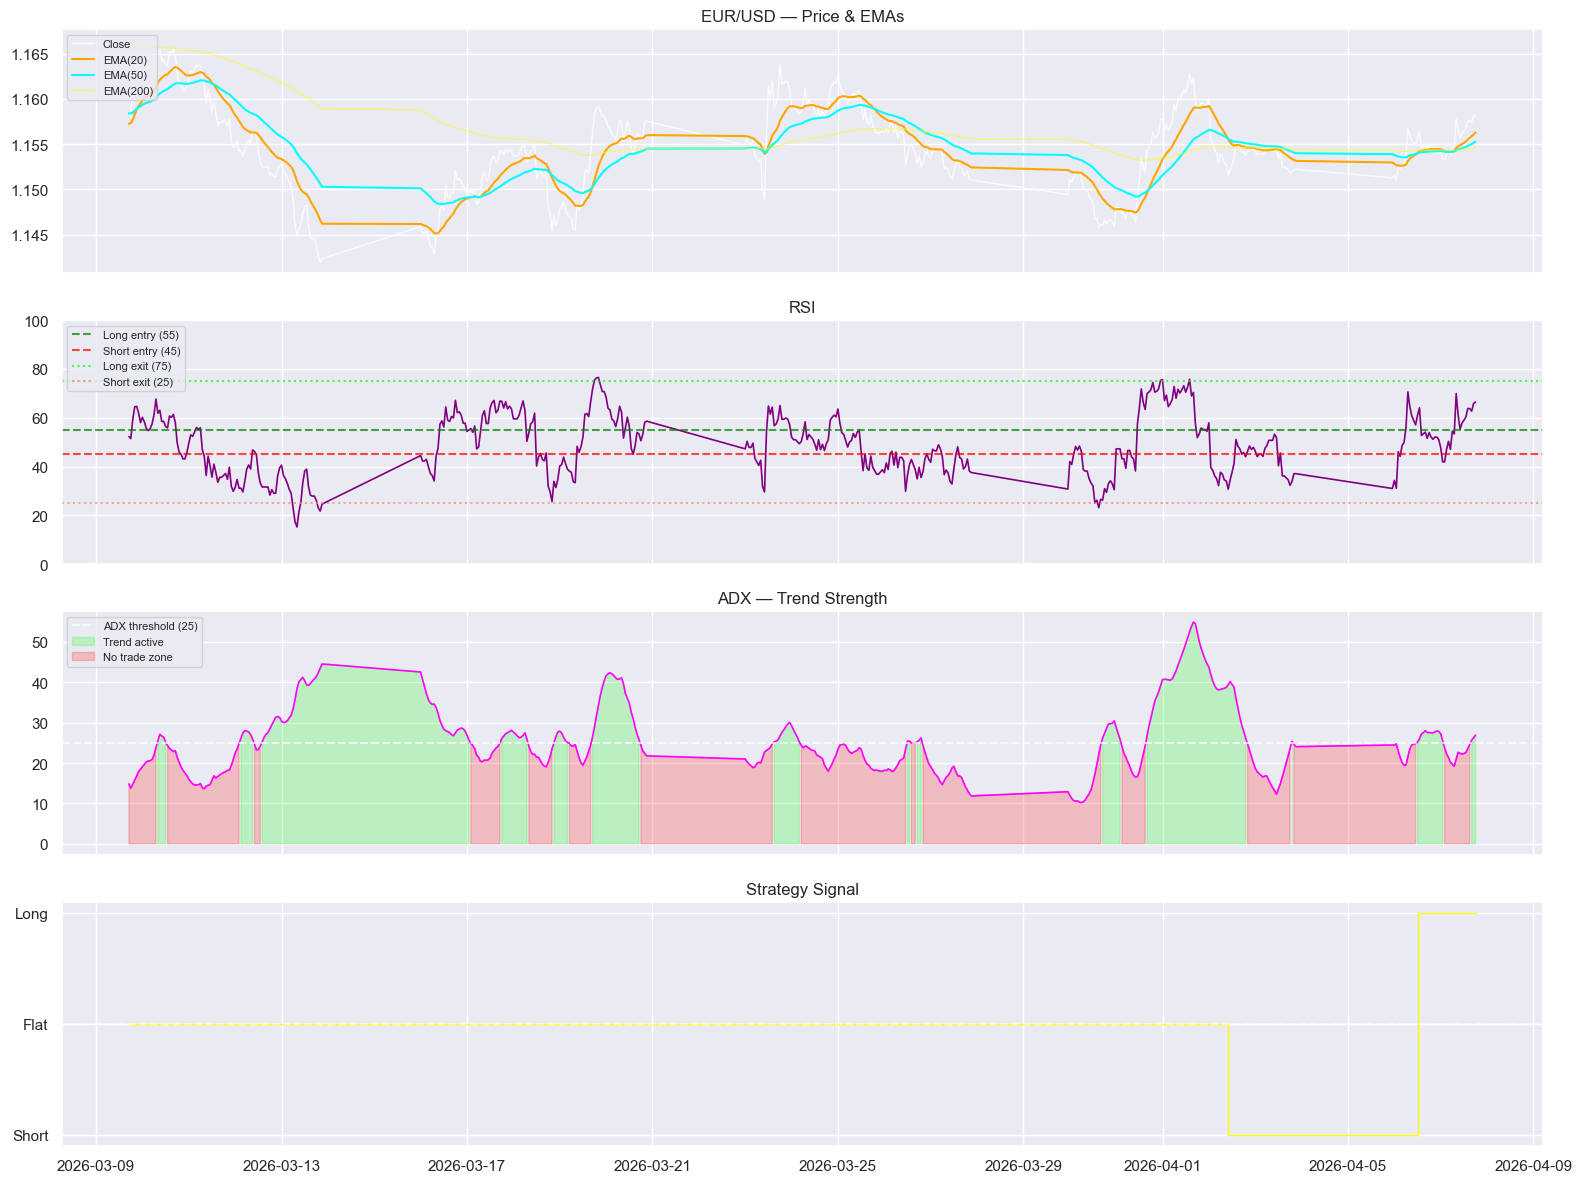

In [6]:
# Visualise indicators — auto-select first available pair
if not processed_data:
    raise RuntimeError('processed_data is empty.')

sample_pair = 'EURUSD=X' if 'EURUSD=X' in processed_data else next(iter(processed_data))
print(f'Plotting: {PAIR_NAMES.get(sample_pair, sample_pair)}')
df_plot = processed_data[sample_pair].iloc[-500:]

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# 1. Price + EMAs
axes[0].plot(df_plot.index, df_plot['Close'],    color='white',  lw=1,   alpha=0.8, label='Close')
axes[0].plot(df_plot.index, df_plot['ema_fast'],  color='orange', lw=1.5, label=f'EMA({FAST_WINDOW})')
axes[0].plot(df_plot.index, df_plot['ema_slow'],  color='cyan',   lw=1.5, label=f'EMA({SLOW_WINDOW})')
axes[0].plot(df_plot.index, df_plot['ema_trend'], color='yellow', lw=1,   alpha=0.5, label=f'EMA({TREND_WINDOW})')
axes[0].set_title(f'{PAIR_NAMES.get(sample_pair)} — Price & EMAs')
axes[0].legend(loc='upper left', fontsize=8)

# 2. RSI with entry and exit thresholds
axes[1].plot(df_plot.index, df_plot['rsi'], color='purple', lw=1.2)
axes[1].axhline(RSI_LONG_THRESH,  color='green', ls='--', alpha=0.7, label=f'Long entry ({RSI_LONG_THRESH})')
axes[1].axhline(RSI_SHORT_THRESH, color='red',   ls='--', alpha=0.7, label=f'Short entry ({RSI_SHORT_THRESH})')
axes[1].axhline(RSI_EXIT_LONG,    color='lime',  ls=':',  alpha=0.7, label=f'Long exit ({RSI_EXIT_LONG})')
axes[1].axhline(RSI_EXIT_SHORT,   color='salmon', ls=':', alpha=0.7, label=f'Short exit ({RSI_EXIT_SHORT})')
axes[1].set_ylim(0, 100)
axes[1].set_title('RSI')
axes[1].legend(loc='upper left', fontsize=8)

# 3. ADX with threshold
axes[2].plot(df_plot.index, df_plot['adx'], color='magenta', lw=1.2)
axes[2].axhline(ADX_THRESHOLD, color='white', ls='--', alpha=0.7, label=f'ADX threshold ({ADX_THRESHOLD})')
axes[2].fill_between(df_plot.index, 0, df_plot['adx'].values,
                     where=df_plot['adx'].values >= ADX_THRESHOLD,
                     alpha=0.2, color='lime', label='Trend active')
axes[2].fill_between(df_plot.index, 0, df_plot['adx'].values,
                     where=df_plot['adx'].values < ADX_THRESHOLD,
                     alpha=0.2, color='red', label='No trade zone')
axes[2].set_title('ADX — Trend Strength')
axes[2].legend(loc='upper left', fontsize=8)

# 4. Signal
axes[3].plot(df_plot.index, df_plot['signal'], color='yellow', lw=1, drawstyle='steps-post')
axes[3].axhline(0, color='white', ls='--', alpha=0.5)
axes[3].set_yticks([-1, 0, 1])
axes[3].set_yticklabels(['Short', 'Flat', 'Long'])
axes[3].set_title('Strategy Signal')

plt.tight_layout()
plt.show()


## 4. Event-Based Backtesting Engine

In [7]:
# ─────────────────────────────────────────────────────────────────
#  DATA CLASSES  — core objects used by the event-based engine
# ─────────────────────────────────────────────────────────────────

@dataclass
class Trade:
    """Represents a completed round-trip trade."""
    pair:        str
    direction:   int          # +1 long, -1 short
    entry_time:  pd.Timestamp
    entry_price: float
    exit_time:   pd.Timestamp
    exit_price:  float
    units:       float        # Lot size in base currency units
    pnl_pips:    float = 0.0  # PnL in pips
    pnl_usd:     float = 0.0  # PnL in USD
    exit_reason: str = ''     # 'signal', 'stop_loss', 'end_of_data'


@dataclass
class Position:
    """Represents an open position."""
    pair:        str
    direction:   int
    entry_time:  pd.Timestamp
    entry_price: float
    units:       float
    stop_loss:   float
    atr_at_entry: float
    trailing_stop: float = 0.0  # Updated each bar to lock in profits


@dataclass
class Portfolio:
    """Tracks portfolio state throughout the backtest."""
    cash:        float
    positions:   Dict[str, Optional[Position]] = field(default_factory=dict)
    trade_log:   List[Trade] = field(default_factory=list)
    equity_curve: List[Tuple] = field(default_factory=list)  # (timestamp, equity)

    def equity(self, prices: Dict[str, float]) -> float:
        """Compute current total equity (cash + open position unrealised PnL)."""
        total = self.cash
        for pair, pos in self.positions.items():
            if pos is not None and pair in prices:
                total += _unrealised_pnl(pos, prices[pair])
        return total


def _pip_size(pair: str) -> float:
    """Return pip size for a pair (0.01 for JPY pairs, else 0.0001)."""
    return 0.01 if 'JPY' in pair.upper() or pair in ('JPY=X',) else 0.0001


def _spread_cost(pair: str, direction: int, spread_pips: float) -> float:
    """Return the spread cost applied on entry (always against the trader)."""
    return direction * spread_pips * _pip_size(pair)


def _pnl_usd(pair: str, pnl_pips: float, pip: float,
             units: float, exit_price: float) -> float:
    """
    USD-base pair currency conversion.
    For USD/JPY, USD/CHF, USD/CAD: price is in foreign-CCY per 1 USD.
    PnL in those foreign units must be divided by exit_price to get USD.
    For EUR/USD, GBP/USD, AUD/USD, NZD/USD: price is already USD per foreign
    unit, so raw_pnl is already in USD (no conversion needed).
    """
    raw_pnl = pnl_pips * pip * units
    if pair in USD_BASE_PAIRS and exit_price > 0:
        return raw_pnl / exit_price
    return raw_pnl


def _unrealised_pnl(pos: Position, current_price: float) -> float:
    """
    Calculate unrealised USD PnL for an open position.
    BUG FIX: now reuses _pnl_usd so USD-base pairs (USD/JPY, USD/CHF, USD/CAD)
    have their floating PnL correctly converted to USD. Previously the unrealised
    PnL was left in the quote currency, which corrupted equity_curve and made
    Sharpe / MaxDD inaccurate whenever any USD-base pair held a position.
    """
    pip = _pip_size(pos.pair)
    pnl_pips = (current_price - pos.entry_price) * pos.direction / pip
    return _pnl_usd(pos.pair, pnl_pips, pip, pos.units, current_price)


def _compute_units(equity: float, risk_frac: float, atr: float,
                    stop_pips: float, pip: float, leverage: float,
                    price: float, pair: str) -> float:
    """
    Size position so that stop-loss distance = risk_frac * equity (in USD).

    BUG FIX: for USD-base pairs (USD/JPY, USD/CHF, USD/CAD) the raw
        units = risk_usd / stop_dist
    sizes risk in the QUOTE currency, not USD. The actual USD loss at the
    stop is (stop_dist * units) / price, so to make that equal to risk_usd
    we must multiply units by `price`. For non-USD-base pairs the original
    formula is already in USD and no adjustment is needed.
    """
    risk_usd  = equity * risk_frac
    stop_dist = stop_pips * pip          # price distance to stop
    if stop_dist == 0:
        return 0
    units = risk_usd / stop_dist
    if pair in USD_BASE_PAIRS:
        units = units * price            # convert quote-CCY risk → USD risk
    # Cap at leverage limit
    max_units = (equity * leverage) / price
    return min(units, max_units)


print("Event-based engine data classes defined.")

Event-based engine data classes defined.


In [8]:
# ─────────────────────────────────────────────────────────────────
#  EVENT-BASED BACKTESTING ENGINE
# ─────────────────────────────────────────────────────────────────

def run_backtest(
    data: Dict[str, pd.DataFrame],
    initial_capital: float = INITIAL_CAPITAL,
    risk_per_trade:  float = RISK_PER_TRADE,
    spread_pips:     float = SPREAD_PIPS,
    atr_stop_mult:   float = ATR_STOP_MULT,  # ATR multiplier for stop-loss distance
    verbose:         bool  = False
) -> Portfolio:
    """
    Event-based backtest engine.

    For each timestamp (event), the engine:
      1. Checks stop-loss hits for open positions.
      2. Reads the new signal for each pair.
      3. If signal differs from current position, closes the old position
         and opens a new one (or goes flat).
      4. Records the equity at each bar.
    """

    portfolio = Portfolio(
        cash=initial_capital,
        positions={pair: None for pair in data}
    )

    # Build a unified sorted timeline of all bar timestamps
    all_times = sorted(set(
        ts for df in data.values() for ts in df.index
    ))

    for ts in all_times:
        # Current prices for equity calculation
        current_prices = {
            pair: df.at[ts, 'Close']
            for pair, df in data.items()
            if ts in df.index
        }

        current_equity = portfolio.equity(current_prices)

        for pair, df in data.items():
            if ts not in df.index:
                continue

            row   = df.loc[ts]
            price = row['Close']
            atr   = row['atr']
            pip   = _pip_size(pair)
            atr_pips = atr / pip
            stop_pips = atr_pips * atr_stop_mult
            new_signal = int(row['signal'])

            # ── STEP 1: Check stop-loss ──────────────────────────────
            bar_low  = row['Low']
            bar_high = row['High']
            pos = portfolio.positions[pair]
            if pos is not None:
                hit_stop = (
                    (pos.direction == 1  and bar_low  <= pos.stop_loss) or
                    (pos.direction == -1 and bar_high >= pos.stop_loss)
                )
                if hit_stop:
                    exit_price = pos.stop_loss
                    pnl_pips   = (exit_price - pos.entry_price) * pos.direction / pip
                    pnl_usd    = _pnl_usd(pair, pnl_pips, pip, pos.units, exit_price)
                    portfolio.cash += pnl_usd
                    portfolio.trade_log.append(Trade(
                        pair=pair, direction=pos.direction,
                        entry_time=pos.entry_time, entry_price=pos.entry_price,
                        exit_time=ts, exit_price=exit_price,
                        units=pos.units, pnl_pips=pnl_pips,
                        pnl_usd=pnl_usd, exit_reason='stop_loss'
                    ))
                    portfolio.positions[pair] = None
                    if verbose:
                        print(f"  STOP   {ts} {PAIR_NAMES.get(pair,pair)} pnl={pnl_usd:.2f}")
                    pos = None

            # ── STEP 1B: Update trailing stop ──────────────────────
            pos = portfolio.positions[pair]
            if pos is not None:
                trail_dist = atr * TRAIL_ATR_MULT
                if pos.direction == 1:
                    new_trail = price - trail_dist
                    if new_trail > pos.trailing_stop:
                        pos.trailing_stop = new_trail
                        if pos.trailing_stop > pos.stop_loss:
                            pos.stop_loss = pos.trailing_stop
                elif pos.direction == -1:
                    new_trail = price + trail_dist
                    if pos.trailing_stop == 0 or new_trail < pos.trailing_stop:
                        pos.trailing_stop = new_trail
                        if pos.trailing_stop < pos.stop_loss:
                            pos.stop_loss = pos.trailing_stop

            # ── STEP 2: Signal change → close existing & open new ────
            current_dir = pos.direction if pos else 0
            if new_signal != current_dir:

                # Close existing position
                if pos is not None:
                    exit_price = price - _spread_cost(pair, pos.direction, spread_pips)
                    pnl_pips   = (exit_price - pos.entry_price) * pos.direction / pip
                    pnl_usd    = _pnl_usd(pair, pnl_pips, pip, pos.units, exit_price)
                    portfolio.cash += pnl_usd
                    portfolio.trade_log.append(Trade(
                        pair=pair, direction=pos.direction,
                        entry_time=pos.entry_time, entry_price=pos.entry_price,
                        exit_time=ts, exit_price=exit_price,
                        units=pos.units, pnl_pips=pnl_pips,
                        pnl_usd=pnl_usd, exit_reason='signal'
                    ))
                    portfolio.positions[pair] = None
                    if verbose:
                        print(f"  CLOSE  {ts} {PAIR_NAMES.get(pair,pair)} dir={pos.direction} pnl={pnl_usd:.2f}")

                # Open new position (if signal is not flat)
                if new_signal != 0 and current_equity > 0:
                    entry_price = price + _spread_cost(pair, new_signal, spread_pips)
                    stop_loss   = entry_price - new_signal * stop_pips * pip
                    units = _compute_units(
                        equity=current_equity,
                        risk_frac=risk_per_trade,
                        atr=atr,
                        stop_pips=stop_pips,
                        pip=pip,
                        leverage=LEVERAGE,
                        price=entry_price,
                        pair=pair,                    # FIX: pass pair for USD-base conversion
                    )
                    if units > 0:
                        init_trail = entry_price - new_signal * atr * TRAIL_ATR_MULT
                        portfolio.positions[pair] = Position(
                            pair=pair, direction=new_signal,
                            entry_time=ts, entry_price=entry_price,
                            units=units, stop_loss=stop_loss,
                            atr_at_entry=atr,
                            trailing_stop=init_trail
                        )
                        if verbose:
                            print(f"  OPEN   {ts} {PAIR_NAMES.get(pair,pair)} dir={new_signal} units={units:.0f} stop={stop_loss:.5f}")

        # ── STEP 3: Record equity ─────────────────────────────────
        portfolio.equity_curve.append((ts, portfolio.equity(current_prices)))

    # ── Close all remaining open positions at each pair's OWN last bar ──
    # FIX: previously used `current_prices` (the loop's last iteration's local
    # variable), which would silently miss any pair whose final bar wasn't the
    # global last timestamp. Now each pair is closed at its own last available
    # Close price and timestamp, guaranteeing every open position is flattened.
    for pair, pos in portfolio.positions.items():
        if pos is None:
            continue
        df_pair = data[pair]
        if df_pair.empty:
            continue
        last_ts    = df_pair.index[-1]
        last_price = df_pair['Close'].iloc[-1]
        pip        = _pip_size(pair)
        pnl_pips   = (last_price - pos.entry_price) * pos.direction / pip
        pnl_usd    = _pnl_usd(pair, pnl_pips, pip, pos.units, last_price)
        portfolio.cash += pnl_usd
        portfolio.trade_log.append(Trade(
            pair=pair, direction=pos.direction,
            entry_time=pos.entry_time, entry_price=pos.entry_price,
            exit_time=last_ts, exit_price=last_price,
            units=pos.units, pnl_pips=pnl_pips,
            pnl_usd=pnl_usd, exit_reason='end_of_data'
        ))
        portfolio.positions[pair] = None

    return portfolio


print("Backtesting engine defined.")

Backtesting engine defined.


## 5. Train / Test Split & Run Backtest

In [9]:
def split_and_process(
    raw_data:    Dict[str, pd.DataFrame],
    train_ratio: float,
    fast:        int = FAST_WINDOW,
    slow:        int = SLOW_WINDOW,
    trend_win:   int = TREND_WINDOW,
    rsi_window:  int = RSI_WINDOW
) -> Tuple[Dict, Dict]:
    """
    FIXED v2: Compute indicators on the FULL raw history (so EMA(200) warm-up
    is paid out of the very first bars and not wasted at the train/test seam),
    then split into train/test and RE-FORWARD-FILL the signal column inside
    each split independently.

    Why this is correct:
      - All indicators here (EMA / RSI / ATR / ADX) are strictly causal
        (EWM with min_periods), so computing them on the full series gives
        identical values to computing them on each split — except the test
        split keeps its full warm-up rather than discarding the first ~200
        bars all over again.
      - `add_indicators` writes signal events into `signal_update` (NaN
        between events) BEFORE forward-filling. We slice that column inside
        each split and re-ffill, so the test set's first signal is computed
        only from test-period crossovers — never inherited from a train-period
        crossover.
    """
    # Step 1: compute indicators ONCE on the full history
    full = {pair: add_indicators(df, fast=fast, slow=slow,
                                 trend_win=trend_win, rsi_window=rsi_window)
            for pair, df in raw_data.items()}

    # Step 2: pick the train/test cut-off from the unified timeline
    all_times = sorted(set(ts for df in full.values() for ts in df.index))
    if not all_times:
        raise RuntimeError("No data after indicator computation.")
    cutoff = all_times[int(len(all_times) * train_ratio)]
    print(f'Train: up to {cutoff.date()} | Test: {cutoff.date()} onwards')

    # Step 3: slice each pair and re-ffill the signal INSIDE each slice so
    # the forward-fill never crosses the train/test boundary.
    def _slice(df: pd.DataFrame, mask) -> pd.DataFrame:
        d = df[mask].copy()
        if 'signal_update' in d.columns:
            d['signal'] = d['signal_update'].ffill().fillna(0).astype(int)
        return d

    train_data = {pair: _slice(df, df.index <= cutoff) for pair, df in full.items()}
    test_data  = {pair: _slice(df, df.index >  cutoff) for pair, df in full.items()}
    return train_data, test_data


train_data, test_data = split_and_process(raw_data, TRAIN_RATIO)
print('\nTrain set sizes:')
for pair in PAIRS:
    if pair in train_data:
        print(f'  {PAIR_NAMES[pair]:10s}: {len(train_data[pair]):,} bars')
print('\nTest set sizes:')
for pair in PAIRS:
    if pair in test_data:
        print(f'  {PAIR_NAMES[pair]:10s}: {len(test_data[pair]):,} bars')


Train: up to 2025-09-11 | Test: 2025-09-11 onwards

Train set sizes:
  EUR/USD   : 8,137 bars
  GBP/USD   : 8,137 bars
  USD/JPY   : 8,090 bars
  USD/CHF   : 8,109 bars
  AUD/USD   : 8,171 bars
  USD/CAD   : 8,172 bars
  NZD/USD   : 8,171 bars

Test set sizes:
  EUR/USD   : 3,463 bars
  GBP/USD   : 3,465 bars
  USD/JPY   : 3,443 bars
  USD/CHF   : 3,451 bars
  AUD/USD   : 3,494 bars
  USD/CAD   : 3,495 bars
  NZD/USD   : 3,494 bars


In [10]:
# Run backtest on TRAIN set
print('Running backtest on TRAIN set...')
portfolio_train = run_backtest(train_data, initial_capital=INITIAL_CAPITAL,
                               risk_per_trade=RISK_PER_TRADE,
                               atr_stop_mult=ATR_STOP_MULT, verbose=False)
print(f'Trades executed (train): {len(portfolio_train.trade_log)}')

# Run backtest on TEST set
print('\nRunning backtest on TEST set...')
portfolio_test = run_backtest(test_data, initial_capital=INITIAL_CAPITAL,
                              risk_per_trade=RISK_PER_TRADE,
                              atr_stop_mult=ATR_STOP_MULT, verbose=False)
print(f'Trades executed (test) : {len(portfolio_test.trade_log)}')

total = len(portfolio_train.trade_log) + len(portfolio_test.trade_log)
print(f'\nTotal trades: {total}')


Running backtest on TRAIN set...
Trades executed (train): 193

Running backtest on TEST set...
Trades executed (test) : 84

Total trades: 277


## 6. Performance Metrics

In [11]:
def compute_metrics(portfolio: Portfolio, label: str = '') -> pd.Series:
    """
    Compute key performance metrics from a completed backtest.
    """
    trades = portfolio.trade_log
    eq_df  = pd.DataFrame(portfolio.equity_curve, columns=['time', 'equity'])
    eq_df.set_index('time', inplace=True)
    eq_df.sort_index(inplace=True)

    if eq_df.empty or len(trades) == 0:
        return pd.Series({'Error': 'No data'})

    equity = eq_df['equity']
    returns = equity.pct_change().dropna()

    # FIX: forex spot trades ~24h/day but ONLY 5 days/week (no Sat/Sun bars).
    # Correct hourly bars per year = 24 * 5 * 52 = 6240. The previous value
    # 8736 (= 24*364) over-counted by ~40%, deflating annualised return and
    # inflating annualised vol → biased Sharpe ratio.
    HOURS_PER_YEAR_FX = 24 * 5 * 52   # 6240

    n_hours    = len(equity)
    n_years_fx = n_hours / HOURS_PER_YEAR_FX if n_hours > 0 else 1

    total_return = (equity.iloc[-1] / equity.iloc[0]) - 1
    ann_return   = (1 + total_return) ** (1 / max(n_years_fx, 0.1)) - 1
    ann_vol      = returns.std() * np.sqrt(HOURS_PER_YEAR_FX)
    excess_ann   = ann_return - RISK_FREE_RATE
    sharpe       = excess_ann / ann_vol if ann_vol != 0 else 0

    # Max drawdown
    roll_max    = equity.cummax()
    drawdown    = (equity - roll_max) / roll_max
    max_dd      = drawdown.min()
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else 0

    # Trade statistics
    pnls   = [t.pnl_usd for t in trades]
    wins   = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p < 0]

    win_rate      = len(wins) / len(pnls) if pnls else 0
    gross_profit  = sum(wins)
    gross_loss    = abs(sum(losses))
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
    avg_win       = np.mean(wins)   if wins   else 0
    avg_loss      = np.mean(losses) if losses else 0
    avg_pnl       = np.mean(pnls)   if pnls   else 0

    metrics = pd.Series({
        'Label':               label,
        'Total Return (%)':    round(total_return * 100, 2),
        'Ann. Return (%)':     round(ann_return   * 100, 2),
        'Ann. Volatility (%)': round(ann_vol      * 100, 2),
        'Sharpe Ratio':        round(sharpe, 3),
        'Max Drawdown (%)':    round(max_dd  * 100, 2),
        'Calmar Ratio':        round(calmar, 3),
        'Win Rate (%)':        round(win_rate * 100, 2),
        'Profit Factor':       round(profit_factor, 3),
        'Avg Win (USD)':       round(avg_win,  2),
        'Avg Loss (USD)':      round(avg_loss, 2),
        'Total Trades':        len(trades),
        'Avg PnL / Trade':     round(avg_pnl, 2),
        'Final Equity (USD)':  round(equity.iloc[-1], 2),
    })
    return metrics


metrics_train = compute_metrics(portfolio_train, 'Train')
metrics_test  = compute_metrics(portfolio_test,  'Test')

comparison = pd.DataFrame([metrics_train, metrics_test]).set_index('Label').T
print("\n=== Strategy Performance Comparison ===")
print(comparison.to_string())


=== Strategy Performance Comparison ===
Label                   Train      Test
Total Return (%)      -19.440    -6.620
Ann. Return (%)       -15.190   -11.480
Ann. Volatility (%)    12.220    11.380
Sharpe Ratio           -1.570    -1.360
Max Drawdown (%)      -23.070    -9.950
Calmar Ratio           -0.659    -1.153
Win Rate (%)           34.720    35.710
Profit Factor           0.674     0.730
Avg Win (USD)          59.970    59.790
Avg Loss (USD)        -47.310   -45.480
Total Trades          193.000    84.000
Avg PnL / Trade       -10.070    -7.880
Final Equity (USD)   8056.310  9338.040


In [12]:
# Per-pair breakdown
def per_pair_metrics(portfolio: Portfolio) -> pd.DataFrame:
    """Break down performance by pair."""
    rows = []
    for pair in PAIRS:
        pair_trades = [t for t in portfolio.trade_log if t.pair == pair]
        if not pair_trades:
            continue
        pnls  = [t.pnl_usd for t in pair_trades]
        wins  = [p for p in pnls if p > 0]
        rows.append({
            'Pair':            PAIR_NAMES.get(pair, pair),
            'Trades':          len(pnls),
            'Win Rate (%)':    round(len(wins)/len(pnls)*100, 1),
            'Total PnL (USD)': round(sum(pnls), 2),
            'Avg PnL (USD)':   round(np.mean(pnls), 2),
            'Best (USD)':      round(max(pnls), 2),
            'Worst (USD)':     round(min(pnls), 2),
        })
    return pd.DataFrame(rows).sort_values('Total PnL (USD)', ascending=False)


print("=== Per-Pair Performance — TRAIN ===")
print(per_pair_metrics(portfolio_train).to_string(index=False))
print("\n=== Per-Pair Performance — TEST ===")
print(per_pair_metrics(portfolio_test).to_string(index=False))

=== Per-Pair Performance — TRAIN ===
   Pair  Trades  Win Rate (%)  Total PnL (USD)  Avg PnL (USD)  Best (USD)  Worst (USD)
GBP/USD      22          40.9            37.05           1.68      169.48       -98.14
USD/JPY      11          27.3            -1.81          -0.16       18.47       -17.48
EUR/USD      29          37.9           -62.12          -2.14      289.65       -97.77
USD/CAD      13          38.5           -71.12          -5.47      110.62       -71.30
NZD/USD      30          43.3          -235.79          -7.86      183.46       -97.25
USD/CHF      57          35.1          -793.63         -13.92      196.58       -96.63
AUD/USD      31          19.4          -816.27         -26.33      128.88       -96.65

=== Per-Pair Performance — TEST ===
   Pair  Trades  Win Rate (%)  Total PnL (USD)  Avg PnL (USD)  Best (USD)  Worst (USD)
AUD/USD      12          33.3           452.69          37.72      352.16      -101.14
EUR/USD      10          60.0            41.85          

## 7. Visualisations

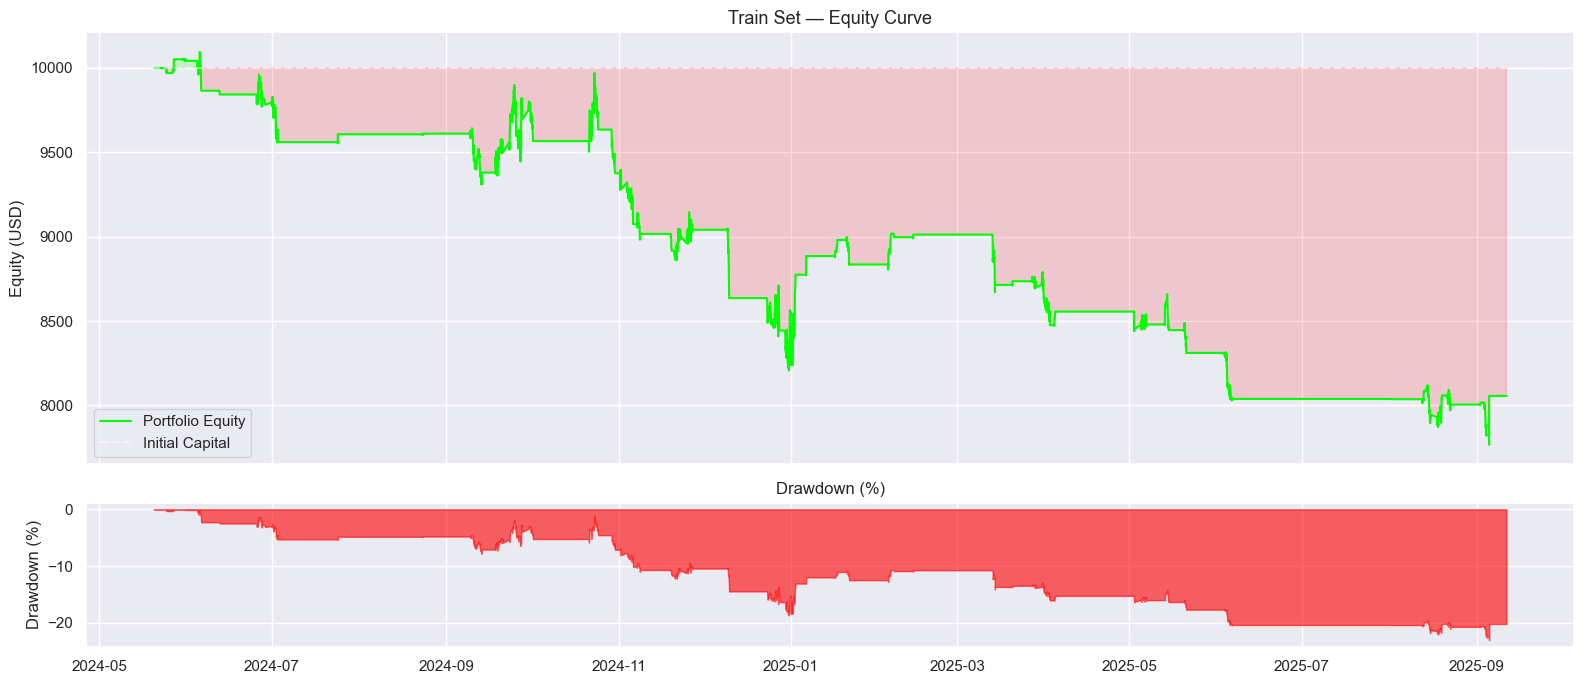

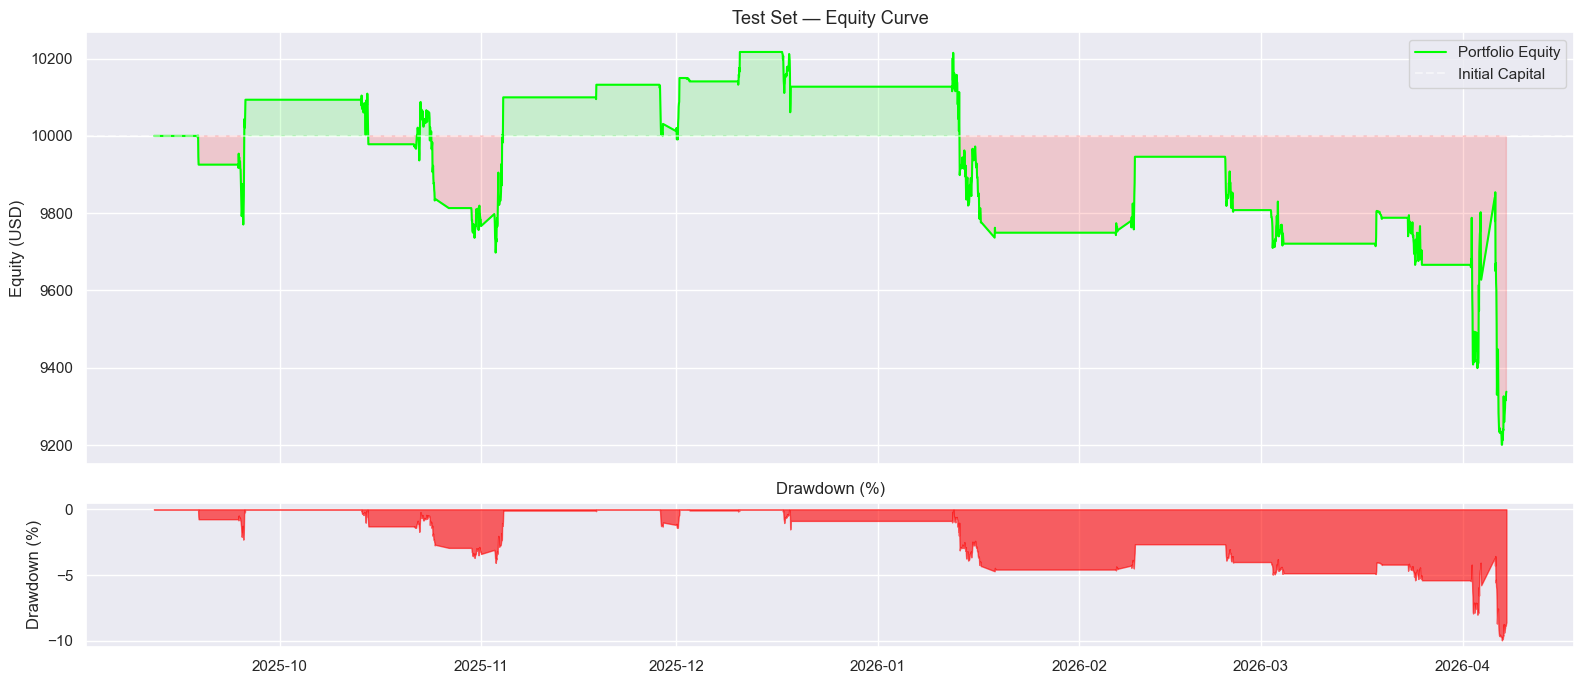

In [13]:
def plot_equity_curve(portfolio: Portfolio, title: str):
    """Plot equity curve and drawdown."""
    eq_df = pd.DataFrame(portfolio.equity_curve, columns=['time', 'equity'])
    eq_df.set_index('time', inplace=True)
    equity   = eq_df['equity']
    roll_max = equity.cummax()
    drawdown = (equity - roll_max) / roll_max * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(equity.index, equity.values, color='lime', lw=1.5, label='Portfolio Equity')
    ax1.axhline(INITIAL_CAPITAL, color='white', linestyle='--', alpha=0.5, label='Initial Capital')
    ax1.fill_between(equity.index, INITIAL_CAPITAL, equity.values,
                     where=(equity.values >= INITIAL_CAPITAL), alpha=0.15, color='lime')
    ax1.fill_between(equity.index, INITIAL_CAPITAL, equity.values,
                     where=(equity.values <  INITIAL_CAPITAL), alpha=0.15, color='red')
    ax1.set_title(f'{title} — Equity Curve', fontsize=13)
    ax1.set_ylabel('Equity (USD)')
    ax1.legend()

    ax2.fill_between(drawdown.index, 0, drawdown.values, color='red', alpha=0.6)
    ax2.set_title('Drawdown (%)')
    ax2.set_ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()


plot_equity_curve(portfolio_train, 'Train Set')
plot_equity_curve(portfolio_test,  'Test Set')

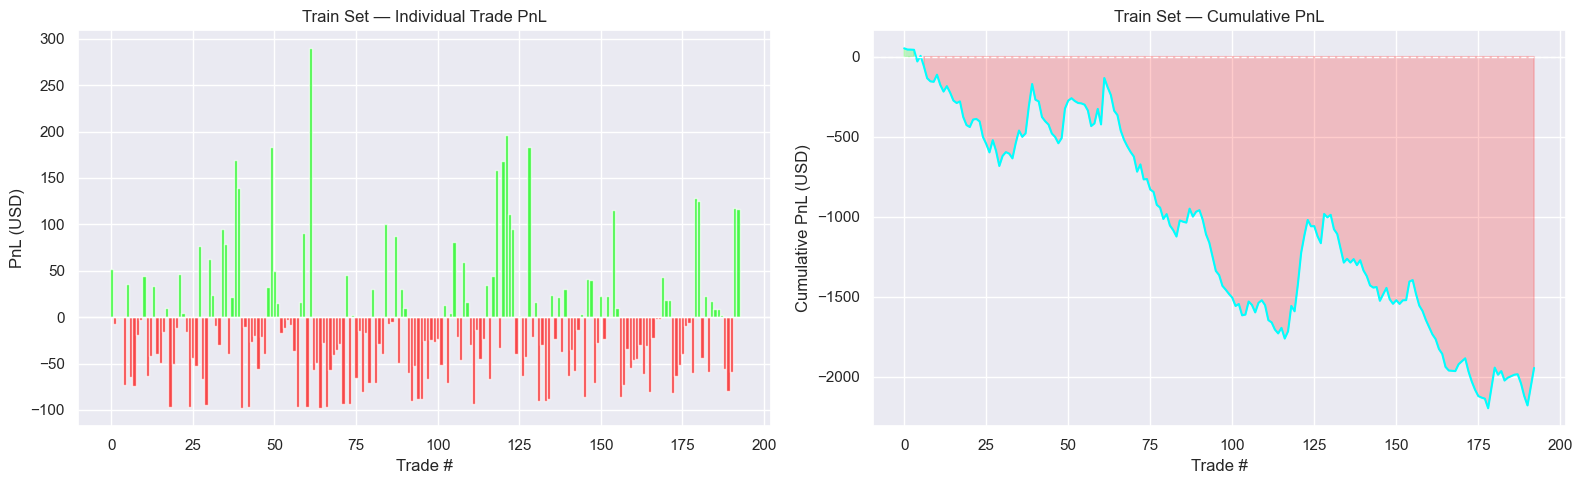

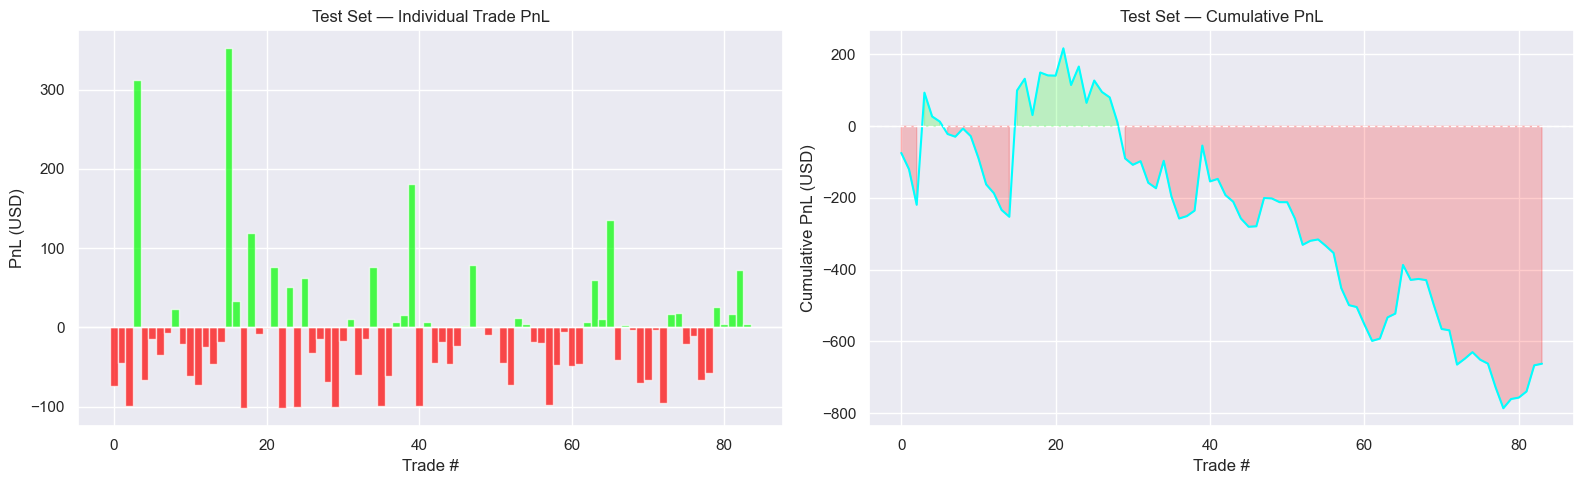

In [14]:
def plot_trade_analysis(portfolio: Portfolio, title: str):
    """Plot trade PnL distribution and cumulative PnL."""
    pnls  = [t.pnl_usd for t in portfolio.trade_log]
    if not pnls:
        print("No trades to analyse.")
        return

    cum_pnl = np.cumsum(pnls)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # PnL distribution
    colours = ['lime' if p > 0 else 'red' for p in pnls]
    ax1.bar(range(len(pnls)), pnls, color=colours, alpha=0.7, width=1.0)
    ax1.axhline(0, color='white', lw=1)
    ax1.set_title(f'{title} — Individual Trade PnL')
    ax1.set_xlabel('Trade #')
    ax1.set_ylabel('PnL (USD)')

    # Cumulative PnL
    ax2.plot(cum_pnl, color='cyan', lw=1.5)
    ax2.axhline(0, color='white', lw=1, linestyle='--')
    ax2.fill_between(range(len(cum_pnl)), 0, cum_pnl,
                     where=(cum_pnl >= 0), alpha=0.2, color='lime')
    ax2.fill_between(range(len(cum_pnl)), 0, cum_pnl,
                     where=(cum_pnl <  0), alpha=0.2, color='red')
    ax2.set_title(f'{title} — Cumulative PnL')
    ax2.set_xlabel('Trade #')
    ax2.set_ylabel('Cumulative PnL (USD)')

    plt.tight_layout()
    plt.show()


plot_trade_analysis(portfolio_train, 'Train Set')
plot_trade_analysis(portfolio_test,  'Test Set')

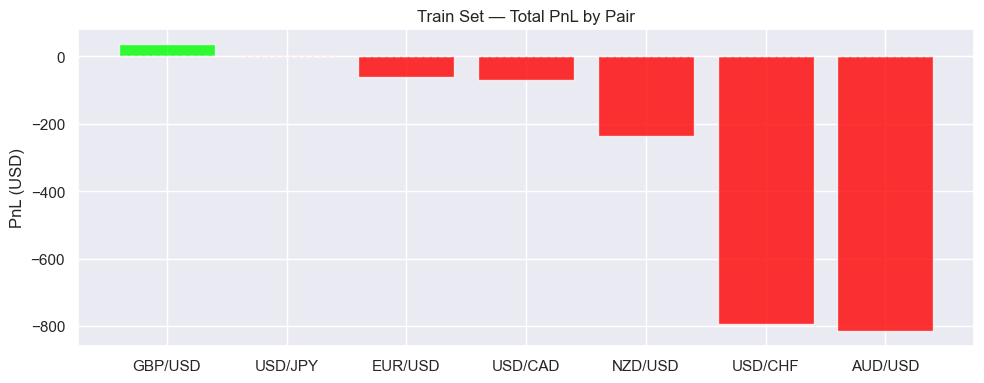

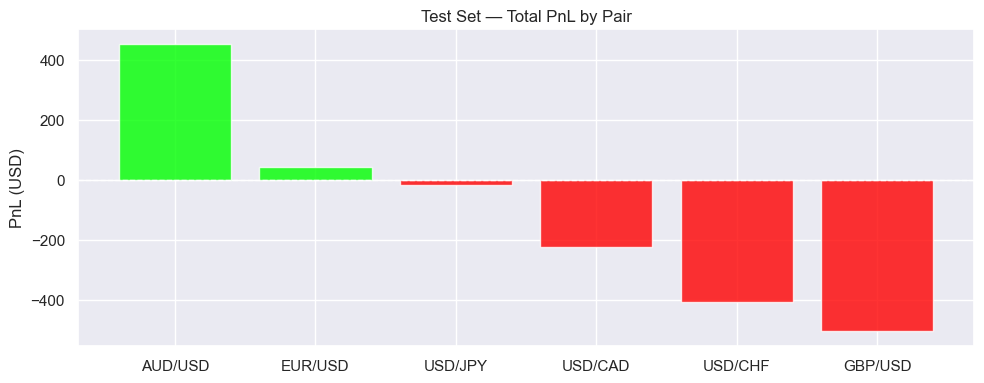

In [15]:
def plot_pair_pnl(portfolio: Portfolio, title: str):
    """Bar chart of total PnL by pair."""
    df = per_pair_metrics(portfolio)
    if df.empty:
        return
    colours = ['lime' if p > 0 else 'red' for p in df['Total PnL (USD)']]
    plt.figure(figsize=(10, 4))
    plt.bar(df['Pair'], df['Total PnL (USD)'], color=colours, alpha=0.8)
    plt.axhline(0, color='white', lw=1, linestyle='--')
    plt.title(f'{title} — Total PnL by Pair')
    plt.ylabel('PnL (USD)')
    plt.tight_layout()
    plt.show()


plot_pair_pnl(portfolio_train, 'Train Set')
plot_pair_pnl(portfolio_test,  'Test Set')

## 8. Parameter Optimisation (Train Set Only)

In [16]:
# ─────────────────────────────────────────────────────────────────
#  Grid Search over EMA windows (train set only)
#  WARNING: Can be slow. Reduce the ranges if needed.
# ─────────────────────────────────────────────────────────────────

def optimise_parameters(
    raw_data:    Dict[str, pd.DataFrame],
    fast_range:  list = [10, 15, 20, 25],
    slow_range:  list = [40, 50, 60, 80],
    rsi_range:   list = [14],
    train_ratio: float = TRAIN_RATIO
) -> pd.DataFrame:
    """
    Grid search over EMA and RSI parameters.
    Evaluates Sharpe Ratio on the TRAIN set.
    """
    results = []
    combos  = list(itertools.product(fast_range, slow_range, rsi_range))
    valid   = [(f, s, r) for f, s, r in combos if f < s]  # fast must be < slow
    print(f"Testing {len(valid)} parameter combinations...")

    for fast, slow, rsi_w in valid:
        # FIX: split raw data first, then compute indicators per split
        # This prevents signal forward-fill from bleeding into test
        train, _ = split_and_process(raw_data, train_ratio,
                                     fast=fast, slow=slow, rsi_window=rsi_w)

        port   = run_backtest(train, verbose=False)
        m      = compute_metrics(port)
        results.append({
            'fast': fast, 'slow': slow, 'rsi': rsi_w,
            'sharpe': m['Sharpe Ratio'],
            'return': m['Total Return (%)'],
            'max_dd': m['Max Drawdown (%)'],
            'trades': m['Total Trades'],
        })

    df_res = pd.DataFrame(results).sort_values('sharpe', ascending=False)
    return df_res


# Run optimisation — use small grid for speed; expand as desired
opt_results = optimise_parameters(
    raw_data,
    fast_range=[10, 20, 30],
    slow_range=[40, 50, 60],
    rsi_range=[14]
)

print("\nTop 10 parameter combinations by Sharpe Ratio (Train):")
print(opt_results.head(10).to_string(index=False))

Testing 9 parameter combinations...
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards
Train: up to 2025-09-11 | Test: 2025-09-11 onwards

Top 10 parameter combinations by Sharpe Ratio (Train):
 fast  slow  rsi  sharpe  return  max_dd  trades
   10    40   14  -0.661   -3.06   -9.01     176
   10    50   14  -0.946   -6.85  -10.28     173
   10    60   14  -1.281  -10.43  -15.36     171
   20    50   14  -1.570  -19.44  -23.07     193
   30    40   14  -1.913  -23.67  -28.07     209
   30    60   14  -2.012  -23.89  -28.90     242
   30    50   14  -2.084  -22.77  -26.22     199
   20    40   14  -2.246  -26.66  -29.16     187
   20   

In [17]:
# Pick the best parameters and re-run on both sets
best = opt_results.iloc[0]
print(f"Best parameters: EMA({int(best.fast)}/{int(best.slow)}), RSI({int(best.rsi)})")
print(f"Train Sharpe: {best.sharpe:.3f} | Train Return: {best['return']:.2f}%")

BEST_FAST = int(best.fast)
BEST_SLOW = int(best.slow)
BEST_RSI  = int(best.rsi)

# FIX: split raw data first, THEN compute indicators independently per split
best_train, best_test = split_and_process(raw_data, TRAIN_RATIO,
                                          fast=BEST_FAST, slow=BEST_SLOW,
                                          rsi_window=BEST_RSI)

print("\nRunning final backtest with best parameters...")
final_train = run_backtest(best_train)
final_test  = run_backtest(best_test)

final_metrics_train = compute_metrics(final_train, 'Train (Best Params)')
final_metrics_test  = compute_metrics(final_test,  'Test  (Best Params)')

final_comparison = pd.DataFrame([final_metrics_train, final_metrics_test]).set_index('Label').T
print("\n=== Final Strategy Performance ===")
print(final_comparison.to_string())

Best parameters: EMA(10/40), RSI(14)
Train Sharpe: -0.661 | Train Return: -3.06%
Train: up to 2025-09-11 | Test: 2025-09-11 onwards

Running final backtest with best parameters...

=== Final Strategy Performance ===
Label                Train (Best Params)  Test  (Best Params)
Total Return (%)                  -3.060                2.870
Ann. Return (%)                   -2.340                5.160
Ann. Volatility (%)                9.600                9.420
Sharpe Ratio                      -0.661                0.123
Max Drawdown (%)                  -9.010               -3.840
Calmar Ratio                      -0.260                1.343
Win Rate (%)                      36.930               39.680
Profit Factor                      0.939                1.169
Avg Win (USD)                     72.670               79.400
Avg Loss (USD)                   -45.310              -44.700
Total Trades                     176.000               63.000
Avg PnL / Trade                   -1.740

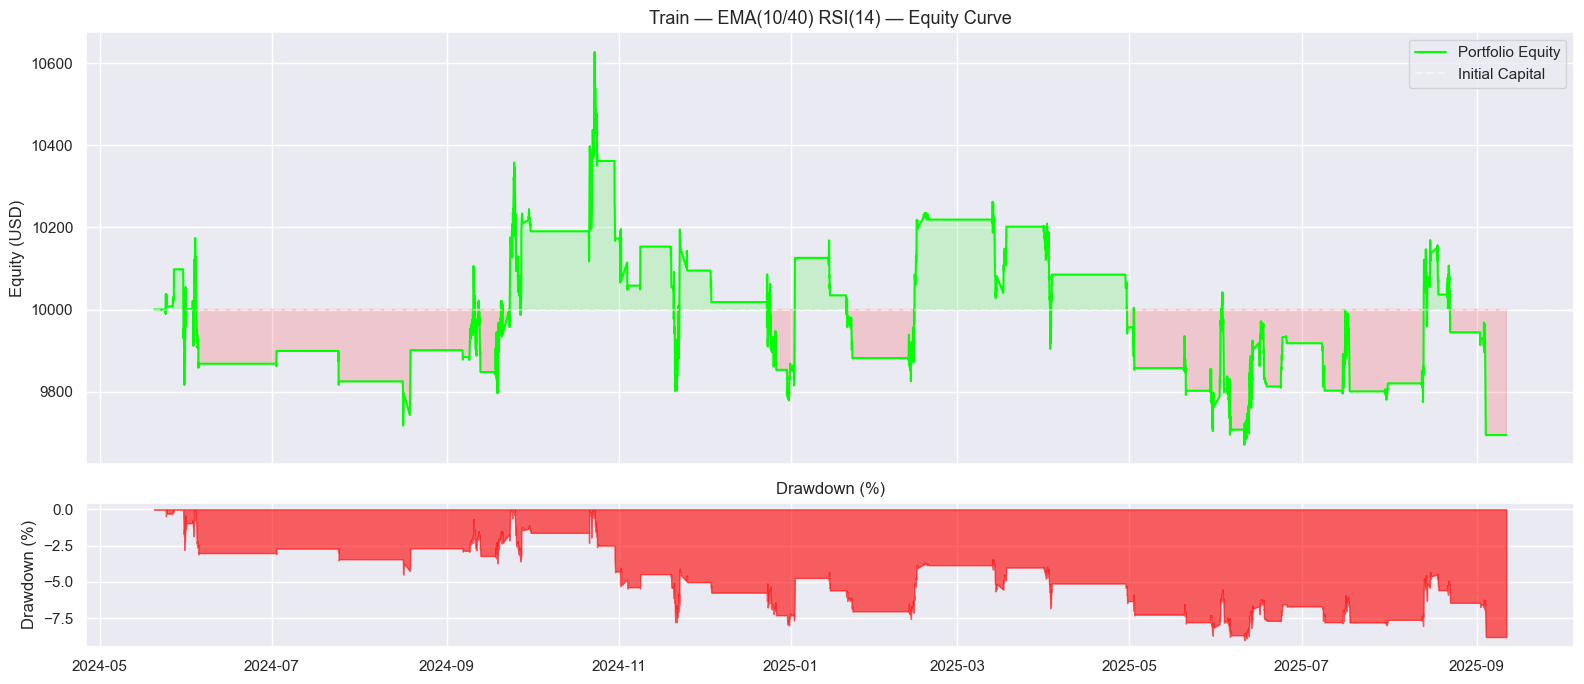

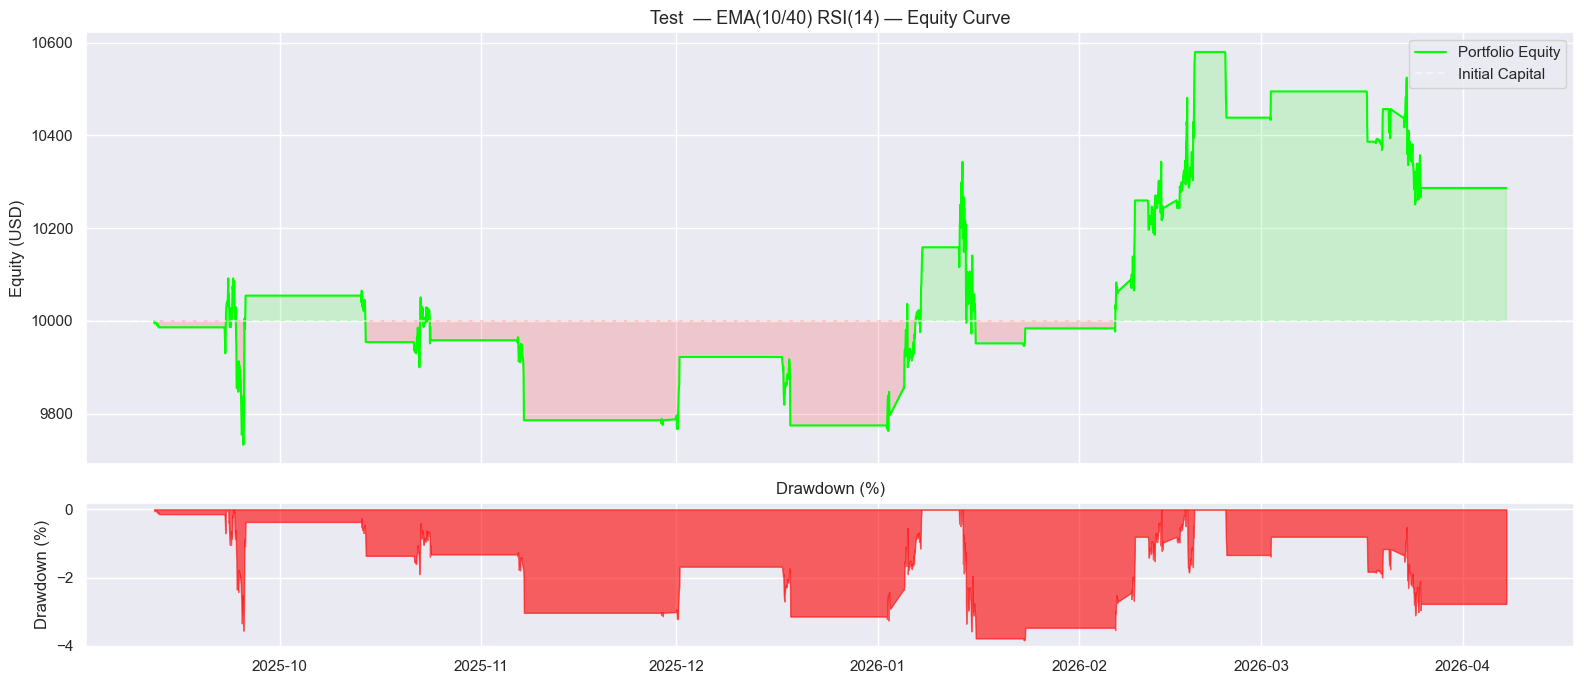

In [18]:
# Final equity curves with best parameters
plot_equity_curve(final_train, f'Train — EMA({BEST_FAST}/{BEST_SLOW}) RSI({BEST_RSI})')
plot_equity_curve(final_test,  f'Test  — EMA({BEST_FAST}/{BEST_SLOW}) RSI({BEST_RSI})')

## 9. Export Trade Log

In [19]:
def trades_to_df(portfolio: Portfolio) -> pd.DataFrame:
    """Convert trade log to a clean DataFrame."""
    rows = []
    for t in portfolio.trade_log:
        rows.append({
            'Pair':         PAIR_NAMES.get(t.pair, t.pair),
            'Direction':    'Long' if t.direction == 1 else 'Short',
            'Entry Time':   t.entry_time,
            'Entry Price':  round(t.entry_price, 5),
            'Exit Time':    t.exit_time,
            'Exit Price':   round(t.exit_price, 5),
            'Units':        round(t.units, 0),
            'PnL Pips':     round(t.pnl_pips, 1),
            'PnL USD':      round(t.pnl_usd, 2),
            'Exit Reason':  t.exit_reason,
        })
    return pd.DataFrame(rows)


df_trades_train = trades_to_df(final_train)
df_trades_test  = trades_to_df(final_test)

# Save to CSV
df_trades_train.to_csv('trades_train.csv', index=False)
df_trades_test.to_csv('trades_test.csv',  index=False)

print(f"Train trades saved: {len(df_trades_train)} rows → trades_train.csv")
print(f"Test  trades saved: {len(df_trades_test)}  rows → trades_test.csv")
print("\nSample trade log (Train):")
df_trades_train.head(10)

Train trades saved: 176 rows → trades_train.csv
Test  trades saved: 63  rows → trades_test.csv

Sample trade log (Train):


,Pair,Direction,Entry Time,Entry Price,Exit Time,Exit Price,Units,PnL Pips,PnL USD,Exit Reason
0,EUR/USD,Long,2024-05-24 11:00:00,1.08480,2024-05-27 09:00:00,1.08676,50042.0,19.6,97.97,signal
1,EUR/USD,Long,2024-05-30 16:00:00,1.08468,2024-05-31 02:00:00,1.08234,43189.0,-23.4,-101.03,stop_loss
2,GBP/USD,Long,2024-05-30 16:00:00,1.27447,2024-05-31 04:00:00,1.27203,30473.0,-24.4,-74.43,signal
3,USD/CAD,Short,2024-05-30 16:00:00,1.36620,2024-05-31 10:00:00,1.36338,30376.0,28.2,62.83,signal
4,USD/JPY,Long,2024-05-31 09:00:00,157.34899,2024-05-31 12:00:00,156.85978,3167.0,-48.9,-9.88,stop_loss
5,USD/JPY,Long,2024-05-31 12:00:00,156.87600,2024-05-31 13:00:00,156.67501,3205.0,-20.1,-4.11,signal
6,USD/JPY,Short,2024-05-31 13:00:00,156.67501,2024-05-31 14:00:00,157.17700,3207.0,-50.2,-10.24,signal
7,AUD/USD,Long,2024-05-30 15:00:00,0.66437,2024-05-31 15:00:00,0.66450,33694.0,1.3,4.51,stop_loss
8,AUD/USD,Long,2024-05-31 15:00:00,0.66434,2024-06-03 05:00:00,0.66436,29048.0,0.2,0.48,stop_loss
9,AUD/USD,Long,2024-06-03 05:00:00,0.66470,2024-06-04 05:00:00,0.66754,43514.0,28.4,123.62,stop_loss


## 10. Benchmark Comparison

We compare the strategy against two benchmarks as required by the project guidelines:

- **Benchmark 1 — EUR/USD Buy & Hold:** Simply buy EUR/USD at the start of the period and hold. This is the most direct forex benchmark.
- **Benchmark 2 — Risk-Free Rate (4% p.a.):** Represents the opportunity cost of holding cash / T-bills instead of trading.


In [20]:
# ─────────────────────────────────────────────────────────────────
#  BENCHMARK COMPARISON
#  Benchmark 1: EUR/USD Buy & Hold
#  Benchmark 2: Risk-Free Rate (4% p.a.)
# ─────────────────────────────────────────────────────────────────

RISK_FREE_RATE = 0.04   # 4% annual risk-free rate

# Forex hourly bars per year (24h × 5 days × 52 weeks). Same constant as in
# compute_metrics so the strategy and the benchmarks are annualised on a
# directly comparable basis.
HOURS_PER_YEAR_FX = 24 * 5 * 52   # 6240


def benchmark_buy_and_hold(price_series: pd.Series,
                           pair: str,
                           initial_capital: float = INITIAL_CAPITAL) -> pd.Series:
    """
    Simulate a simple buy-and-hold on a single forex price series.

    BUG FIX: for USD-base pairs (USD/JPY, USD/CHF, USD/CAD) the quoted price
    is FOREIGN-CCY per 1 USD, so a "buy & hold" expressed as
        equity(t) = price(t) / price(0) * capital
    is actually the value (in USD) of holding the FOREIGN currency, which
    moves OPPOSITE to the way the price is quoted. The correct USD value of
    holding 1 unit of the foreign currency is `1 / price`. We invert the
    series for those pairs so the curve is meaningful.

    For pairs already quoted as USD per foreign unit (EUR/USD, GBP/USD, …)
    no inversion is needed.
    """
    s = price_series.dropna().astype(float)
    if pair in USD_BASE_PAIRS:
        s = 1.0 / s    # convert FOREIGN/USD → USD/FOREIGN
    entry_price = s.iloc[0]
    equity      = s / entry_price * initial_capital
    return equity.rename('equity')


def benchmark_risk_free(index: pd.DatetimeIndex,
                        initial_capital: float = INITIAL_CAPITAL,
                        annual_rate: float = RISK_FREE_RATE) -> pd.Series:
    """
    Compound risk-free growth curve over a given DatetimeIndex.
    Uses forex-hour compounding consistent with HOURS_PER_YEAR_FX.
    """
    n_hours    = len(index)
    r_hourly   = (1 + annual_rate) ** (1 / HOURS_PER_YEAR_FX) - 1
    growth     = (1 + r_hourly) ** np.arange(n_hours)
    return pd.Series(initial_capital * growth, index=index, name='equity')


def strategy_equity_series(portfolio: Portfolio) -> pd.Series:
    """Extract the equity curve from a portfolio as a clean Series."""
    eq = pd.DataFrame(portfolio.equity_curve, columns=['time', 'equity'])
    eq.set_index('time', inplace=True)
    return eq['equity'].sort_index()


def compute_benchmark_metrics(equity: pd.Series, label: str,
                               initial_capital: float = INITIAL_CAPITAL) -> pd.Series:
    """Compute the same performance metrics for a benchmark equity curve."""
    returns     = equity.pct_change().dropna()
    n_hours     = len(equity)
    n_years     = n_hours / HOURS_PER_YEAR_FX if n_hours > 0 else 1
    total_ret   = (equity.iloc[-1] / equity.iloc[0]) - 1
    ann_ret     = (1 + total_ret) ** (1 / max(n_years, 0.1)) - 1
    ann_vol     = returns.std() * np.sqrt(HOURS_PER_YEAR_FX)
    sharpe      = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol != 0 else 0
    roll_max    = equity.cummax()
    max_dd      = ((equity - roll_max) / roll_max).min()
    calmar      = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return pd.Series({
        'Label':               label,
        'Total Return (%)':    round(total_ret * 100, 2),
        'Ann. Return (%)':     round(ann_ret   * 100, 2),
        'Ann. Volatility (%)': round(ann_vol   * 100, 2),
        'Sharpe Ratio':        round(sharpe, 3),
        'Max Drawdown (%)':    round(max_dd  * 100, 2),
        'Calmar Ratio':        round(calmar, 3),
        'Win Rate (%)':        '-',
        'Profit Factor':       '-',
        'Total Trades':        1,
        'Final Equity (USD)':  round(equity.iloc[-1], 2),
    })


# ── Build benchmark equity curves (using TEST set period) ─────────
print('Building benchmark curves...')

# Strategy equity on test set
strat_eq = strategy_equity_series(final_test)

# Benchmark 1: prefer EUR/USD; otherwise pick a non-USD-base pair so the
# buy-and-hold curve is unambiguous. Falls back to inversion via
# benchmark_buy_and_hold if a USD-base pair is the only option.
if 'EURUSD=X' in best_test:
    bm_pair = 'EURUSD=X'
else:
    non_usd_base = [p for p in best_test if p not in USD_BASE_PAIRS]
    bm_pair = non_usd_base[0] if non_usd_base else next(iter(best_test))

bm_prices = best_test[bm_pair]['Close'].reindex(strat_eq.index).ffill().dropna()
bh_eq = benchmark_buy_and_hold(bm_prices, pair=bm_pair)

# Align to same index
common_idx = strat_eq.index.intersection(bh_eq.index)
strat_eq   = strat_eq.reindex(common_idx).ffill()
bh_eq      = bh_eq.reindex(common_idx).ffill()

# Benchmark 2: Risk-Free Rate
rf_eq = benchmark_risk_free(common_idx, INITIAL_CAPITAL, RISK_FREE_RATE)

print(f'Benchmark   : {PAIR_NAMES.get(bm_pair, bm_pair)} Buy & Hold')
print(f'Test period : {common_idx[0].date()} → {common_idx[-1].date()}')
print(f'Bars        : {len(common_idx):,}')

Building benchmark curves...
Benchmark   : EUR/USD Buy & Hold
Test period : 2025-09-11 → 2026-04-07
Bars        : 3,506


In [21]:
# ── Side-by-side metrics: Strategy vs Both Benchmarks ─────────────
m_strategy = compute_metrics(final_test, 'Strategy (Test)')
m_bh       = compute_benchmark_metrics(bh_eq, f'{PAIR_NAMES.get(bm_pair, bm_pair)} Buy & Hold')
m_rf       = compute_benchmark_metrics(rf_eq, 'Risk-Free (4% p.a.)')

comparison = pd.DataFrame([m_strategy, m_bh, m_rf]).set_index('Label').T
print('=== Strategy vs Benchmarks (Test Set) ===')
print(comparison.to_string())

print('\nInterpretation:')
strat_sharpe = float(m_strategy['Sharpe Ratio'])
bh_sharpe    = float(m_bh['Sharpe Ratio'])
if strat_sharpe > bh_sharpe:
    print(f'  ✓ Strategy Sharpe ({strat_sharpe:.3f}) > Buy & Hold Sharpe ({bh_sharpe:.3f})')
    print('    Strategy delivers better risk-adjusted returns than passive holding.')
else:
    print(f'  ✗ Strategy Sharpe ({strat_sharpe:.3f}) < Buy & Hold Sharpe ({bh_sharpe:.3f})')
    print('    Strategy does not outperform buy & hold on a risk-adjusted basis.')


=== Strategy vs Benchmarks (Test Set) ===
Label               Strategy (Test) EUR/USD Buy & Hold Risk-Free (4% p.a.)
Total Return (%)               2.87              -1.31                2.23
Ann. Return (%)                5.16              -2.32                 4.0
Ann. Volatility (%)            9.42               6.16                 0.0
Sharpe Ratio                  0.123             -1.026     -1129212683.622
Max Drawdown (%)              -3.84              -5.21                 0.0
Calmar Ratio                  1.343             -0.445                 0.0
Win Rate (%)                  39.68                  -                   -
Profit Factor                 1.169                  -                   -
Avg Win (USD)                  79.4                NaN                 NaN
Avg Loss (USD)                -44.7                NaN                 NaN
Total Trades                     63                  1                   1
Avg PnL / Trade                4.55                NaN    

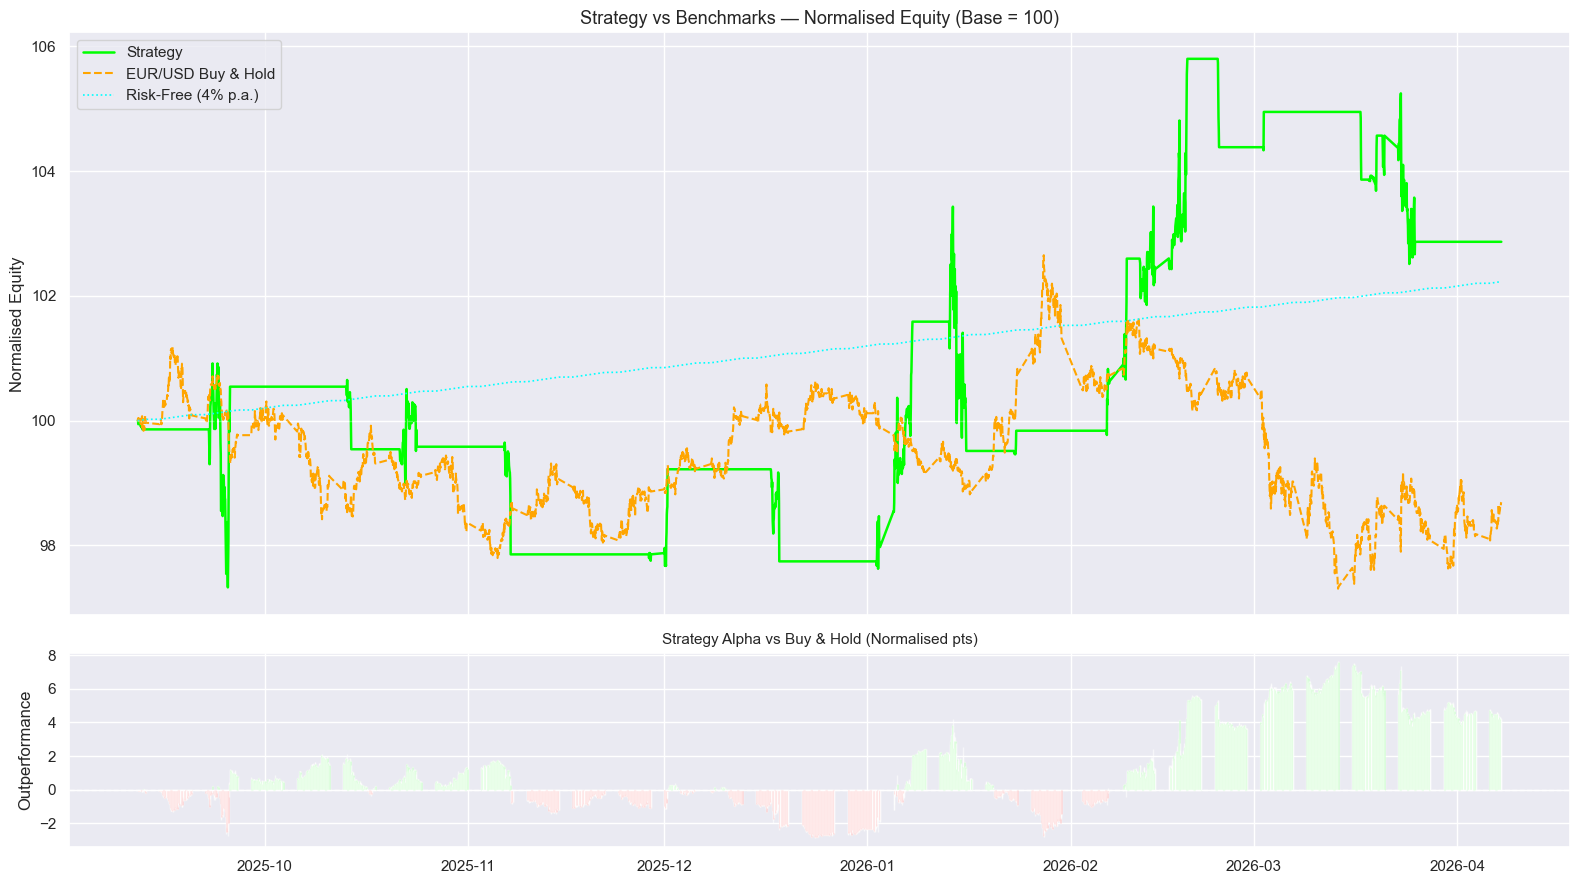

Final equity — Strategy   : $10,286.54
Final equity — Buy & Hold : $9,869.12
Final equity — Risk-Free  : $10,222.75


In [22]:
# ── Plot: Strategy Equity vs Both Benchmarks ─────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Normalise all curves to start at 100 for fair visual comparison
norm_strat = strat_eq / strat_eq.iloc[0] * 100
norm_bh    = bh_eq    / bh_eq.iloc[0]    * 100
norm_rf    = rf_eq    / rf_eq.iloc[0]    * 100

ax1.plot(norm_strat.index, norm_strat.values, color='lime',   lw=1.8,
         label='Strategy')
ax1.plot(norm_bh.index,    norm_bh.values,    color='orange', lw=1.5,
         linestyle='--', label=f'{PAIR_NAMES.get(bm_pair, bm_pair)} Buy & Hold')
ax1.plot(norm_rf.index,    norm_rf.values,    color='cyan',   lw=1.2,
         linestyle=':',  label='Risk-Free (4% p.a.)')
ax1.axhline(100, color='white', linestyle='--', alpha=0.3, lw=1)
ax1.set_title('Strategy vs Benchmarks — Normalised Equity (Base = 100)', fontsize=13)
ax1.set_ylabel('Normalised Equity')
ax1.legend(loc='upper left')

# Relative performance: strategy minus buy-and-hold (in %)
rel_perf = norm_strat.values - norm_bh.reindex(norm_strat.index).ffill().values
colours  = ['lime' if v >= 0 else 'red' for v in rel_perf]
ax2.bar(norm_strat.index, rel_perf, color=colours, alpha=0.6, width=0.04)
ax2.axhline(0, color='white', lw=1, linestyle='--')
ax2.set_title('Strategy Alpha vs Buy & Hold (Normalised pts)', fontsize=11)
ax2.set_ylabel('Outperformance')

plt.tight_layout()
plt.show()

# Final summary numbers
print(f"Final equity — Strategy   : ${strat_eq.iloc[-1]:,.2f}")
print(f"Final equity — Buy & Hold : ${bh_eq.iloc[-1]:,.2f}")
print(f"Final equity — Risk-Free  : ${rf_eq.iloc[-1]:,.2f}")


## 11. Summary

| Item | Detail |
|------|--------|
| **Strategy** | Dual EMA Crossover with RSI Filter |
| **Universe** | USD Major Pairs (7 pairs) |
| **Frequency** | 1-hour bars |
| **Backtester** | Event-based (tick-by-tick signal processing) |
| **Risk Management** | ATR-based stop-loss, 1% equity risk per trade |
| **Spread** | 2 pips simulated |
| **Out-of-sample** | 70% train / 30% test |

### Strengths
- Trend-following strategies work well in forex due to persistent directional moves.
- RSI filter reduces false crossover signals during sideways/choppy markets.
- ATR-based position sizing adapts to current volatility, controlling risk dynamically.
- Multi-pair diversification smooths equity curve.

### Weaknesses
- Lagging indicators mean entries are delayed — misses early trend moves.
- Performs poorly in low-volatility, range-bound markets.
- No consideration for economic calendar events (high-impact news can cause slippage).
- Transaction costs (swap rates, overnight charges) not fully modelled.

### Next Steps
- Implement in real-time mode via OANDA API (see `real_time_trading.py`)
- Add session filters (trade only during London/NY sessions)
- Consider adding trailing stops to lock in profits
